# NB645: Farag et al. 2022 PPI Results — Extraction for PPISNConfig

This notebook examines data on PPI as a function of He and CO core masses from the Farag+2022 5m_2h_25t model:
```fortran
max_dq = 2d-4 ! 5x farmer hydrostatic spatial res
split_merger_amr_nz_baseline = 12000 ! 2x farmer hydrodynamical spatial res
delta_lgRho_cntr_limit = 2.5d-3 ! 25x farmer time res
min_D_mix = 0d0 ! same as farmer
```

With the 2015-temperature points, median (0sigma) DeBoer+2017 c12ag rates, and 1x NACRE 3a rates.

In [1]:
nb_id = 645

import pickle
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.constants import Z_SUN
from src.util import DATA_DIR

plt.style.use('./plotstyle.mplstyle')

FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

## 1. Load and check

In [2]:
FARAG_DATA = Path('/mnt/sds-hd/sd23g011/desa/farag_2022_data/farag2022_2xm_10t_and_2xm_15xt_histories/2xm_25xt/ppi_results.h5')
full_df = pd.read_hdf(FARAG_DATA, key='ppi')
print(f'Shape: {full_df.shape}')
full_df.head()

Shape: (45, 37)


,M_He_init,M_He_He_depl,M_CO_He_depl,center_c12_He_depl,center_o16_He_depl,compactness_He_depl,log_center_T_He_depl,log_center_Rho_He_depl,gamma_integral_He_depl,M_He_C_depl,...,M_BH,compactness_final,center_c12_final,center_o16_final,total_energy_final,star_age_sec_final,gamma_integral_final,Delta_M_PPI,row1_star_mass,filename_mass_mismatch
0,29.0,28.917371,25.215531,0.174029,0.799462,0.025591,8.556291,3.188137,0.065785,28.916172,...,28.916172,0.600647,0.000001,4.846570e-07,-4.282309e+51,1.127192e+13,0.017091,0.083828,29.0,False
1,30.0,29.912744,26.364350,0.178014,0.793328,0.025465,8.556737,3.179851,0.064763,29.911478,...,29.911478,0.481815,0.000001,4.733701e-07,-3.682774e+51,1.107246e+13,0.022205,0.088522,30.0,False
2,31.0,30.908340,27.228922,0.193489,0.779795,0.025335,8.557036,3.171406,0.063802,30.907004,...,30.907004,0.664306,0.000002,8.815211e-07,-3.740395e+51,1.085943e+13,0.026612,0.092996,31.0,False
3,32.0,31.901382,28.163064,0.162521,0.803552,0.025241,8.558071,3.164815,0.062691,31.899982,...,31.899982,0.688223,0.000002,1.143370e-06,-4.898716e+51,1.088745e+13,0.011075,0.100018,32.0,False
4,34.0,33.890383,29.924279,0.161361,0.802519,0.025025,8.559081,3.150455,0.060876,33.888843,...,33.888843,0.515309,0.000002,8.534716e-07,-4.573714e+51,1.065560e+13,0.020033,0.111157,34.0,False


In [3]:
full_df.columns.tolist()

['M_He_init',
 'M_He_He_depl',
 'M_CO_He_depl',
 'center_c12_He_depl',
 'center_o16_He_depl',
 'compactness_He_depl',
 'log_center_T_He_depl',
 'log_center_Rho_He_depl',
 'gamma_integral_He_depl',
 'M_He_C_depl',
 'M_CO_C_depl',
 'center_c12_C_depl',
 'center_o16_C_depl',
 'compactness_C_depl',
 'log_center_T_C_depl',
 'log_center_Rho_C_depl',
 'gamma_integral_C_depl',
 'M_He_O_depl',
 'M_CO_O_depl',
 'center_c12_O_depl',
 'center_o16_O_depl',
 'compactness_O_depl',
 'log_center_T_O_depl',
 'log_center_Rho_O_depl',
 'gamma_integral_O_depl',
 'M_He_final',
 'M_CO_final',
 'M_BH',
 'compactness_final',
 'center_c12_final',
 'center_o16_final',
 'total_energy_final',
 'star_age_sec_final',
 'gamma_integral_final',
 'Delta_M_PPI',
 'row1_star_mass',
 'filename_mass_mismatch']

In [4]:
df = full_df[full_df.filename_mass_mismatch == False].copy()

In [5]:
summary_cols = [
    'M_He_init', 'M_CO_He_depl', 'M_CO_C_depl', 'M_CO_O_depl',
    'M_He_final', 'M_CO_final', 'M_BH', 'Delta_M_PPI',
]
df[summary_cols]

,M_He_init,M_CO_He_depl,M_CO_C_depl,M_CO_O_depl,M_He_final,M_CO_final,M_BH,Delta_M_PPI
0,29.0,25.215531,24.154919,23.869471,28.916172,23.803452,28.916172,0.083828
1,30.0,26.364350,19.441015,18.749663,29.911478,18.749663,29.911478,0.088522
2,31.0,27.228922,23.618453,12.717930,30.907004,12.589670,30.907004,0.092996
3,32.0,28.163064,28.015656,27.915755,31.899982,27.880791,31.899982,0.100018
4,34.0,29.924279,29.144513,28.949274,33.888843,29.462618,33.888843,0.111157
5,35.0,30.930384,30.933526,30.855949,34.884359,30.781358,34.884359,0.115641
6,36.0,31.977399,31.982494,31.915752,35.877736,31.884091,35.877736,0.122264
7,37.0,32.822770,32.828650,32.373839,36.871433,32.991468,36.871433,0.128567
8,38.0,33.897833,33.898054,33.271648,37.865909,33.695196,37.865909,0.134091
9,39.0,34.819589,34.813114,34.813114,38.859739,34.686224,38.859739,0.140261


## 2. Key relationships

Text(0, 0.5, '$M_{\\rm CO}/\\mathrm{M}_\\odot$')

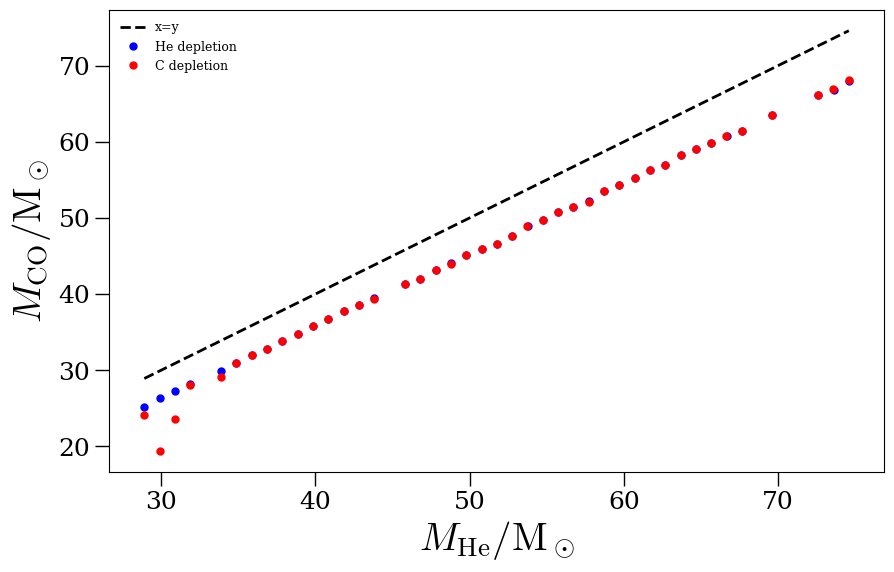

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df.M_He_He_depl, df.M_He_He_depl, 'k--', ms=5, label='x=y', zorder=5)
ax.plot(df.M_He_He_depl, df.M_CO_He_depl, 'bo', ms=5, label='He depletion', zorder=5)
ax.plot(df.M_He_C_depl, df.M_CO_C_depl, 'ro', ms=5, label='C depletion', zorder=5)
ax.legend(fontsize=9, frameon=False)
ax.set_xlabel(r'$M_{\rm He}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm CO}/\mathrm{M}_\odot$')


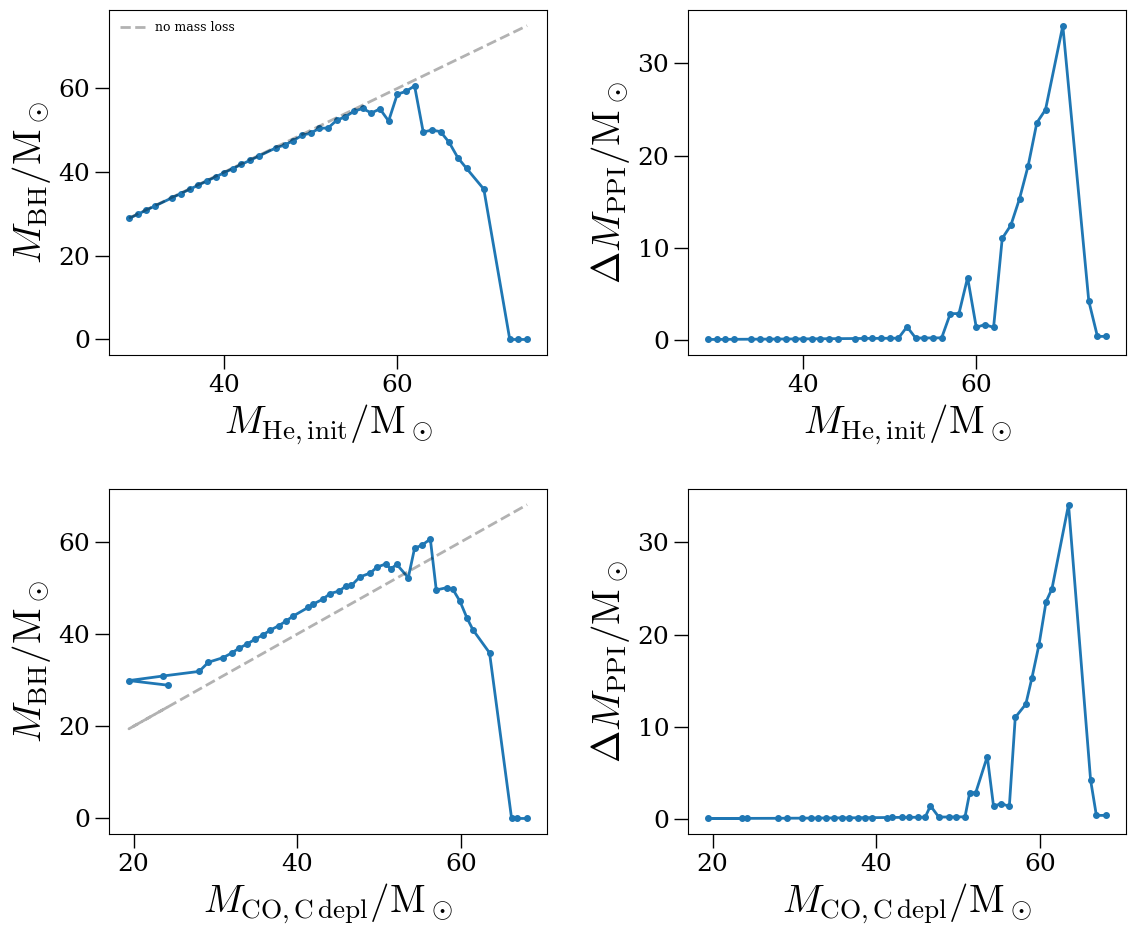

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# M_He_init vs M_BH
ax = axes[0, 0]
ax.plot(df.M_He_init, df.M_BH, 'o-', ms=4)
ax.plot(df.M_He_init, df.M_He_init, 'k--', alpha=0.3, label='no mass loss')
ax.set_xlabel(r'$M_{\rm He,init}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')
ax.legend(fontsize=9, frameon=False)

# M_He_init vs Delta_M_PPI
ax = axes[0, 1]
ax.plot(df.M_He_init, df.Delta_M_PPI, 'o-', ms=4)
ax.set_xlabel(r'$M_{\rm He,init}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$\Delta M_{\rm PPI}/\mathrm{M}_\odot$')

# M_CO at C depletion vs M_BH
ax = axes[1, 0]
valid = df.M_CO_C_depl.notna()
ax.plot(df.M_CO_C_depl[valid], df.M_BH[valid], 'o-', ms=4)
ax.plot(df.M_CO_C_depl[valid], df.M_CO_C_depl[valid], 'k--', alpha=0.3)
ax.set_xlabel(r'$M_{\rm CO, C\,depl}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')

# M_CO at C depletion vs Delta_M_PPI
ax = axes[1, 1]
ax.plot(df.M_CO_C_depl[valid], df.Delta_M_PPI[valid], 'o-', ms=4)
ax.set_xlabel(r'$M_{\rm CO, C\,depl}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$\Delta M_{\rm PPI}/\mathrm{M}_\odot$')

fig.tight_layout()
plt.show()

## 3. Identify fate transitions

Classify each model into CCSN / PPISN / PISN / PD based on the Farag results,
then read off the threshold masses in both M_He and M_CO.

In [8]:
# Farag et al. (2022) state that wind mass loss during He burning is <0.3 Msun
# so this should be >= 0.3
# between 0.3 and 1.4 the classification is the same
# starting from 1.4, the minimum core mass for PPI starts to go up
min_delta_ppi_for_ppisn = 1

# Classify fates from the simulation outcomes
def classify_fate(row):
    if row.M_BH < 0.01:
        return 'pisn'
    if row.Delta_M_PPI > min_delta_ppi_for_ppisn:
        return 'ppisn'
    return 'ccsn'

df['fate'] = df.apply(classify_fate, axis=1)
print(df.groupby('fate').M_He_init.agg(['min', 'max', 'count']))
print()
df[['M_He_init', 'M_CO_C_depl', 'M_BH', 'Delta_M_PPI', 'fate', 'filename_mass_mismatch']]

        min   max  count
fate                    
ccsn   29.0  56.0     25
pisn   73.0  75.0      3
ppisn  52.0  70.0     14



,M_He_init,M_CO_C_depl,M_BH,Delta_M_PPI,fate,filename_mass_mismatch
0,29.0,24.154919,28.916172,0.083828,ccsn,False
1,30.0,19.441015,29.911478,0.088522,ccsn,False
2,31.0,23.618453,30.907004,0.092996,ccsn,False
3,32.0,28.015656,31.899982,0.100018,ccsn,False
4,34.0,29.144513,33.888843,0.111157,ccsn,False
5,35.0,30.933526,34.884359,0.115641,ccsn,False
6,36.0,31.982494,35.877736,0.122264,ccsn,False
7,37.0,32.828650,36.871433,0.128567,ccsn,False
8,38.0,33.898054,37.865909,0.134091,ccsn,False
9,39.0,34.813114,38.859739,0.140261,ccsn,False


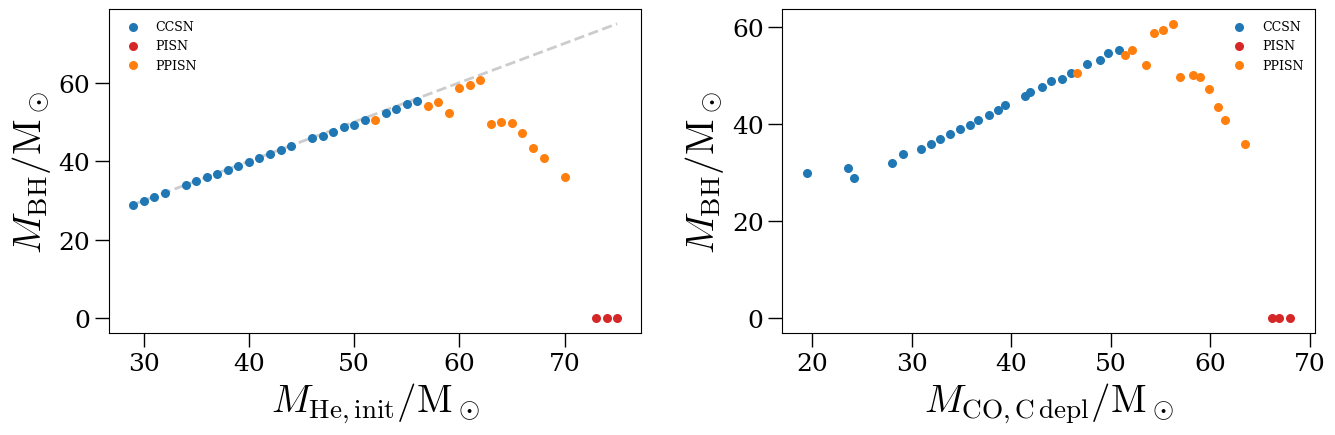

In [9]:
colors = {'ccsn': 'C0', 'ppisn': 'C1', 'pisn': 'C3'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fate, grp in df.groupby('fate'):
    axes[0].scatter(grp.M_He_init, grp.M_BH, label=fate.upper(), color=colors[fate], s=30, zorder=3)
axes[0].plot(df.M_He_init, df.M_He_init, 'k--', alpha=0.2)
axes[0].set_xlabel(r'$M_{\rm He,init}/\mathrm{M}_\odot$')
axes[0].set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')
axes[0].legend(fontsize=9, frameon=False)

valid = df.M_CO_C_depl.notna()
for fate, grp in df[valid].groupby('fate'):
    axes[1].scatter(grp.M_CO_C_depl, grp.M_BH, label=fate.upper(), color=colors[fate], s=30, zorder=3)
axes[1].set_xlabel(r'$M_{\rm CO, C\,depl}/\mathrm{M}_\odot$')
axes[1].set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')
axes[1].legend(fontsize=9, frameon=False)

fig.tight_layout()
plt.show()

## 4. Photodisintegration regime

This is included because the pop synth pipeline this analysis informs has photodisintegration ('pd') as a classification for objects above the PI gap. The model dataset does not actually reach that far up in mass, but Farag+2022 do report for at least some models the upper edge of the PI mass gap (M_BH~135Msun), so this is included as a reminder in case other datasets are used in the future.

In [10]:
print('Models with M_He_init >= 70:')
print(df[df.M_He_init >= 70][['M_He_init', 'M_BH', 'Delta_M_PPI', 'fate']].to_string(index=False))

Models with M_He_init >= 70:
 M_He_init      M_BH  Delta_M_PPI  fate
      70.0 35.928972    34.071028 ppisn
      73.0  0.000006     4.244670  pisn
      74.0  0.000006     0.410979  pisn
      75.0  0.000006     0.418663  pisn


## 5. Build PPISNConfig from Farag data

Limits for PPISN, PISN and PD are set at midpoint thresholds between the last model of one fate and the first of the next. This dataclass structure is used in the pop synth pipeline in NB64. In the absence of data the minimum He core mass for PD is set to 133, which is taken from the Farag+2022 result for DeBoer rates in a lower resolution model (5m_2h_10t_D 1xNACRE 3a).

In [11]:
from src.star import FaragHighResPPISNConfig

In [12]:
# --- He-core thresholds ---
last_ccsn_he = df[df.fate == 'ccsn'].M_He_init.max()
first_ppisn_he = df[df.fate == 'ppisn'].M_He_init.min()
last_ppisn_he = df[df.fate == 'ppisn'].M_He_init.max()
first_pisn_he = df[df.fate == 'pisn'].M_He_init.min()

m_he_ppisn_th = (last_ccsn_he + first_ppisn_he) / 2
m_he_pisn_th = (last_ppisn_he + first_pisn_he) / 2

print(f'He-core PPISN threshold (midpoint): {m_he_ppisn_th:.1f} Msun')
print(f'  (between last CCSN={last_ccsn_he} and first PPISN={first_ppisn_he})')
print(f'He-core PISN threshold (midpoint):  {m_he_pisn_th:.1f} Msun')
print(f'  (between last PPISN={last_ppisn_he} and first PISN={first_pisn_he})')
print()

# --- CO-core thresholds (at C depletion) ---
ccsn_co = df[df.fate == 'ccsn'].M_CO_C_depl
ppisn_co = df[df.fate == 'ppisn'].M_CO_C_depl
pisn_co = df[df.fate == 'pisn'].M_CO_C_depl

if len(ccsn_co) > 0 and len(ppisn_co) > 0:
    m_co_ppisn_th = (ccsn_co.max() + ppisn_co.min()) / 2
    print(f'CO-core PPISN threshold (midpoint): {m_co_ppisn_th:.2f} Msun')
    print(f'  (between last CCSN M_CO={ccsn_co.max():.2f} and first PPISN M_CO={ppisn_co.min():.2f})')

if len(ppisn_co) > 0 and len(pisn_co) > 0:
    m_co_pisn_th = (ppisn_co.max() + pisn_co.min()) / 2
    print(f'CO-core PISN threshold (midpoint):  {m_co_pisn_th:.2f} Msun')
    print(f'  (between last PPISN M_CO={ppisn_co.max():.2f} and first PISN M_CO={pisn_co.min():.2f})')
print()

# PD threshold: not constrained by this grid (max M_He = 75).
# Keep the existing 135 Msun default.
print('PD threshold: not constrained by Farag grid (max M_He=75). Keeping 135 Msun default.')

He-core PPISN threshold (midpoint): 54.0 Msun
  (between last CCSN=56.0 and first PPISN=52.0)
He-core PISN threshold (midpoint):  71.5 Msun
  (between last PPISN=70.0 and first PISN=73.0)

CO-core PPISN threshold (midpoint): 48.72 Msun
  (between last CCSN M_CO=50.83 and first PPISN M_CO=46.62)
CO-core PISN threshold (midpoint):  64.82 Msun
  (between last PPISN M_CO=63.48 and first PISN M_CO=66.17)

PD threshold: not constrained by Farag grid (max M_He=75). Keeping 135 Msun default.


In [13]:
# Construct the fiducial config 
farag_config = FaragHighResPPISNConfig(
    m_he_ppisn=m_he_ppisn_th,
    m_he_pisn=m_he_pisn_th,
    m_co_ppisn=m_co_ppisn_th,
    m_co_pisn=m_co_pisn_th,
)
print(farag_config)
print()
print(f'Using threshold_core="{farag_config.threshold_core}":')
print(f'  ppisn_th = {farag_config.ppisn_th}')
print(f'  pisn_th  = {farag_config.pisn_th}')
print(f'  pd_th    = {farag_config.pd_th}')

FaragHighResPPISNConfig(c3_log_slope=0.0006, c3_intercept=0.0054, c2=-0.0013, m_co_ref=34.8, m_he_ppisn=np.float64(54.0), m_he_pisn=np.float64(71.5), m_he_pd=133, m_co_ppisn=np.float64(48.72378963457675), m_co_pisn=np.float64(64.8230423036793), m_co_pd=133, threshold_core='he')

Using threshold_core="he":
  ppisn_th = 54.0
  pisn_th  = 71.5
  pd_th    = 133


In [14]:
PPISN_CONFIG_PATH = DATA_DIR / 'farag_high_res_ppisn_config.pkl'
with open(PPISN_CONFIG_PATH, 'wb') as f:
    pickle.dump(farag_config, f)
print(f'Wrote {PPISN_CONFIG_PATH}')

Wrote ../data/farag_high_res_ppisn_config.pkl


## 6. Farag M_BH vs Renzo prescription comparison

In [15]:
def renzo_ppisn(m_tot, m_co, z, config=FaragHighResPPISNConfig(threshold_core='co')):
    delta_ppi = (
        (config.c3_log_slope * np.log10(z) + config.c3_intercept)
        * (m_co - config.m_co_ref) ** 3
        - config.c2 * (m_co - config.m_co_ref) ** 2
    )
    delta_ppi = np.clip(delta_ppi, 0.0, None)
    return np.clip(m_tot - delta_ppi, 0.0, None)

 How much does it matter at which point in the evolution we look at the CO core? For the range unambiguously affected by PPI, there is effectively no differnece between He depl and C depl.

In [16]:
# PAIR INSTABILITY THIS
def mapelli_ppisn(m_tot, m_he):

    # Appendix A, Mapelli+20 (https://ui.adsabs.harvard.edu/abs/2020ApJ...888...76M/abstract)
    # (based on fit to the Woosley17 tables, https://ui.adsabs.harvard.edu/abs/2017ApJ...836..244W/abstract)

    # default: no correction, i.e. pisn_correction factor = 1.0, SN type core collapse;
    pisn_correction = 1.0

    # Helium fraction
    he_frac = m_he / m_tot

    # k_param (pisn_correction dependence upon helium fraction)
    k_param = 0.67 * he_frac + 0.1

    # pulsation pair-instability supernova: pulses
    if m_he > 32.0 and m_he < 64.0:
        # use Table 2 fit from Woosley 2017
        if he_frac < 0.9:
            if m_he <= 37.0:
                pisn_correction = (k_param - 1.0) / 5.0 * m_he + (37.0 - 32.0 * k_param) / 5.0
            elif m_he > 37.0 and m_he <= 60.0:
                pisn_correction = k_param
            else:
                pisn_correction = -(k_param / 4.0) * m_he + 16.0 * k_param
                # use WR table 1 fit from Woosley 2017
        else:
            if m_he <= 37.0:
                pisn_correction = (0.5226 * he_frac - 0.52974) * (m_he - 32.0) + 1.0
            elif m_he > 37.0 and m_he <= 56.0:
                val = (0.5226 * he_frac - 0.52974) * 5.0 + 1.0
                if val < 0.82916:
                    pisn_correction = val
                else:
                    pisn_correction = (-0.1381 * he_frac + 0.1309) * (m_he - 56.0) + 0.82916
            else:
                pisn_correction = -0.103645 * m_he + 6.63328

    # pair-instability supernova: disintegrated
    elif m_he >= 64.0 and m_he < 135.0:
        pisn_correction = 0.0

    # end of PISN... again standard direct collapse
    else:
        pisn_correction = 1.0

    corrected_mass = pisn_correction * m_tot

    # The minimum remnant in the Woosley17 tables is 4.5 Msun, we assume
    # that if the PISN correction (pisn_correction!=1) create a final mass
    # below this number the system is actually destroyed by a PISN
    if corrected_mass < 4.5 and pisn_correction != 1:
        corrected_mass = 0.0
    # TODO The alternativa idea below is more similar to what we use now in Farmer (but in Farmer this problem never happens)
    # Alternative idea, now if the corrected mass is below 4.5 Msun, 4.5 Msun is used instead
    # //corrected_mass = std::max(corrected_mass,4.5);

    return corrected_mass


def neutrinos(mrem):
    # Lattimer & Yahil89 mass loss, valid for NSs...
    # Eq. 4 in Giacobbo & Mapelli, 2018 (https://arxiv.org/pdf/1805.11100.pdf)
    mremnant_after = 6.6667 * (np.sqrt(1.0 + 0.3 * mrem) - 1.0)

    Mass_neutrinos = mrem - mremnant_after
    if Mass_neutrinos > 0.5:
        print(Mass_neutrinos)
        mremnant_after = mrem - 0.5  # assuming a Fe core mass = 5 Msun, Zevin, Spera+2020

    return mremnant_after
    # return mrem

Text(0, 0.5, '$M_{\\rm CO}/\\mathrm{M}_\\odot$')

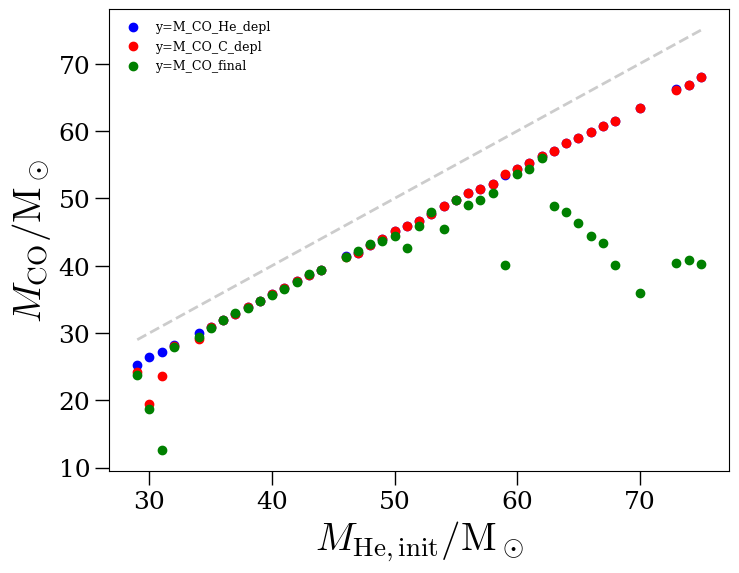

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))


x='M_He_init'
y='M_CO_He_depl'
ax.scatter(df[x], df[y], c='blue', label=f'y={y}')

x='M_He_init'
y='M_CO_C_depl'
ax.scatter(df[x], df[y], c='red', label=f'y={y}')


x='M_He_init'
y='M_CO_final'
ax.scatter(df[x], df[y], c='green', label=f'y={y}')


ax.plot(df[x], df[x], 'k--', alpha=0.2)
ax.legend(fontsize=9, frameon=False)

ax.set_xlabel(r'$M_{\rm He,init}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm CO}/\mathrm{M}_\odot$')

For the comparisons below, $Z=10^{-5}$ is the metallicity used in Farag et al. (2022)

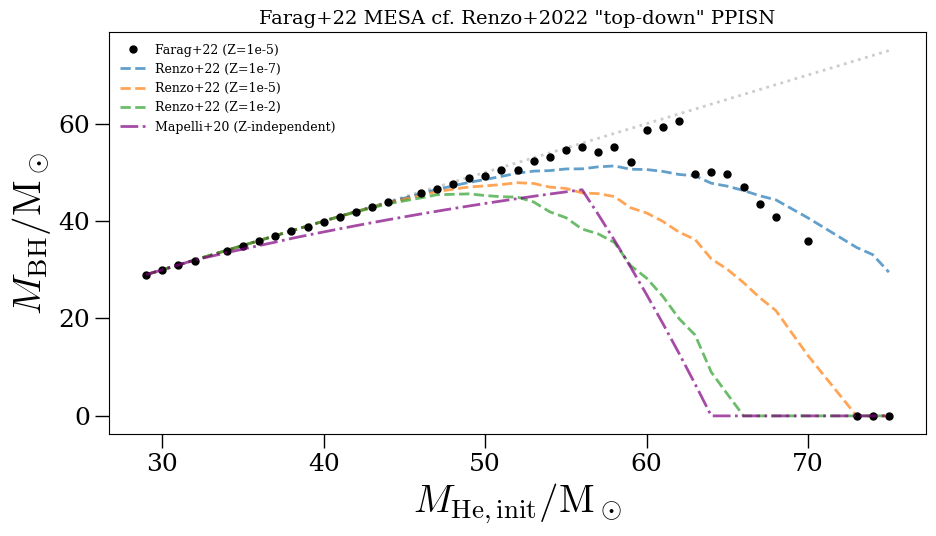

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df.M_He_init, df.M_BH, 'ko', ms=5, label='Farag+22 (Z=1e-5)', zorder=5)

m_he = df.M_He_init.values
m_co = df.M_CO_He_depl.values  # Use CO mass at He depletion for Renzo prescription
for z_label, z_val in [('Z=1e-7', 1e-7), ('Z=1e-5', 1e-5), ('Z=1e-2', 1e-2)]:
    m_bh_renzo = renzo_ppisn(m_he, m_co, z_val)
    ax.plot(m_he, m_bh_renzo, '--', label=f'Renzo+22 ({z_label})', alpha=0.7)

m_bh_mapelli = np.vectorize(mapelli_ppisn)(m_he, m_he)
ax.plot(m_he, m_bh_mapelli, '-.', color='purple', label='Mapelli+20 (Z-independent)', zorder=5, alpha=0.7)

ax.plot(m_he, m_he, 'k:', alpha=0.2)
ax.set_xlabel(r'$M_{\rm He,init}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')
ax.legend(fontsize=9, frameon=False)
ax.set_title('Farag+22 MESA cf. Renzo+2022 "top-down" PPISN', fontsize=14)
fig.tight_layout()
plt.show()

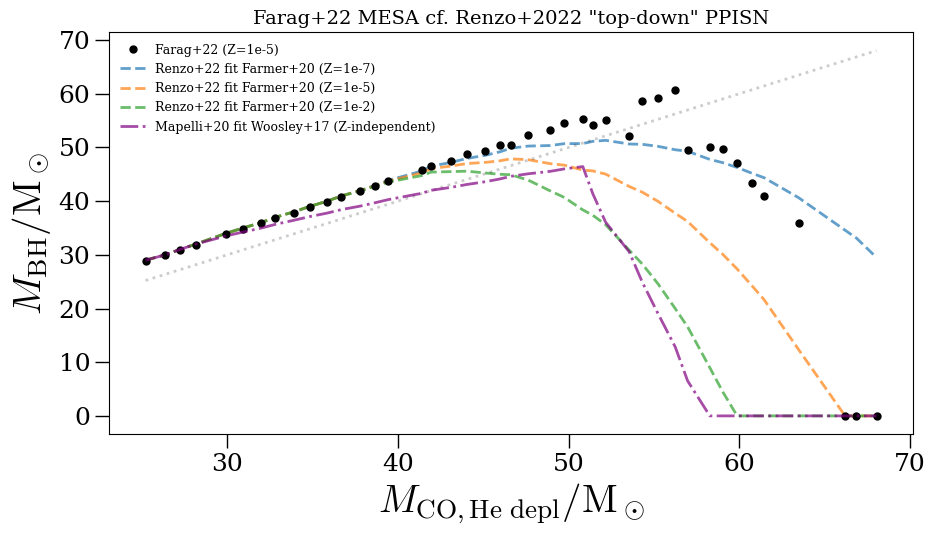

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df.M_CO_He_depl, df.M_BH, 'ko', ms=5, label='Farag+22 (Z=1e-5)', zorder=5)

m_he = df.M_He_init.values
m_co = df.M_CO_He_depl.values  # Use CO mass at He depletion for Renzo prescription
for z_label, z_val in [('Z=1e-7', 1e-7), ('Z=1e-5', 1e-5), ('Z=1e-2', 1e-2)]:
    m_bh_renzo = renzo_ppisn(m_he, m_co, z_val)
    ax.plot(m_co, m_bh_renzo, '--', label=f'Renzo+22 fit Farmer+20 ({z_label})', alpha=0.7)

m_bh_mapelli = np.vectorize(mapelli_ppisn)(m_he, m_he)
ax.plot(m_co, m_bh_mapelli, '-.', color='purple', label='Mapelli+20 fit Woosley+17 (Z-independent)', zorder=5, alpha=0.7)

ax.plot(m_co, m_co, 'k:', alpha=0.2)
ax.set_xlabel(r'$M_{\rm CO,He~depl}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$M_{\rm BH}/\mathrm{M}_\odot$')
ax.legend(fontsize=9, frameon=False)
ax.set_title('Farag+22 MESA cf. Renzo+2022 "top-down" PPISN', fontsize=14)
fig.tight_layout()
plt.show()

(20.0, 70.0)

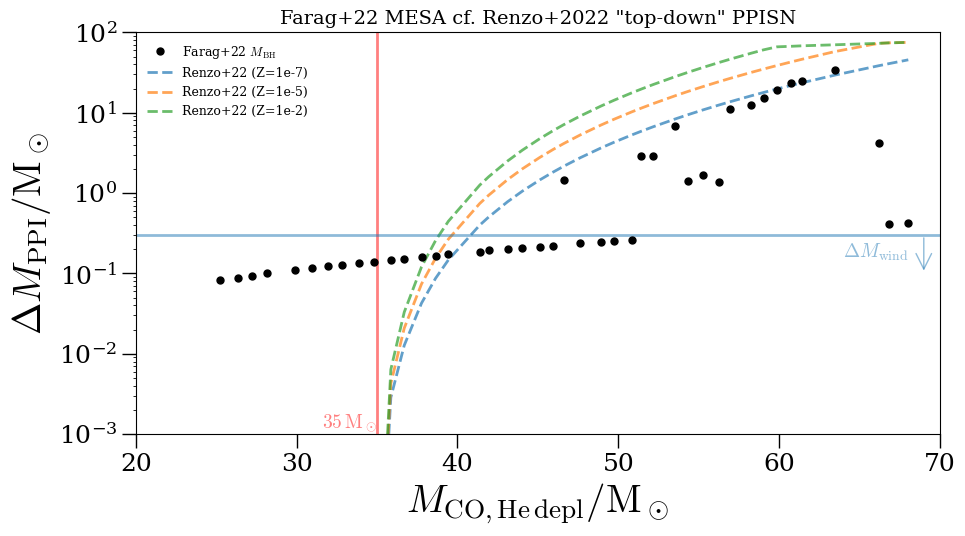

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

m_he = df.M_He_init.values
m_co = df.M_CO_He_depl.values  # Use CO mass at He depletion for Renzo prescription

sort_df_i = np.argsort(m_co)

ax.plot(m_co[sort_df_i], df.M_He_init.values[sort_df_i]-df.M_He_final.values[sort_df_i], 'ko', ms=5, label='Farag+22 $M_{\\rm BH}$', zorder=5)

for z_label, z_val in [('Z=1e-7', 1e-7), ('Z=1e-5', 1e-5), ('Z=1e-2', 1e-2)]:
    m_bh_renzo = renzo_ppisn(m_he, m_co, z_val)
    ax.plot(m_co[sort_df_i], m_he[sort_df_i]-m_bh_renzo[sort_df_i], '--', label=f'Renzo+22 ({z_label})', alpha=0.7)

#ax.plot(m_he, m_he, 'k:', alpha=0.2)
ax.set_xlabel(r'$M_{\rm CO, He\,depl}/\mathrm{M}_\odot$')
ax.set_ylabel(r'$\Delta M_{\rm PPI}/\mathrm{M}_\odot$')
ax.legend(fontsize=9, frameon=False)
ax.set_title('Farag+22 MESA cf. Renzo+2022 "top-down" PPISN', fontsize=14)
fig.tight_layout()
ax.set_yscale('log')
ax.vlines(35, ymin=0.001, ymax=100, colors='r', linestyles='-', alpha=0.5)
ax.text(35, 0.001, r'$35\,{\rm M}_\odot$', color='r', alpha=0.5, ha='right', va='bottom', fontsize=14)
ax.set_ylim(1e-3, 100)


ax.hlines(0.3, xmin=20, xmax=70, colors='C0', alpha=0.5)
ax.annotate(
    '',
    xy=(69, 0.1),
    xytext=(69, 0.3),
    arrowprops=dict(arrowstyle='->', color='C0', alpha=0.5),
)
ax.text(66, 0.25, r'$\Delta M_{\rm wind}$', color='C0', alpha=0.5, ha='center', va='top', fontsize=14)
ax.set_xlim(20, 70)